# 03 - Evaluation

Evaluate the trained model and create final metrics/visualizations.


In [1]:
import sys
from pathlib import Path

print('Notebook Python:', sys.executable)
current = Path.cwd().resolve()
expected_python = None
for path in [current, *current.parents]:
    candidate = path / '.venv' / 'bin' / 'python'
    if candidate.exists():
        expected_python = candidate
        break

if expected_python and Path(sys.executable).resolve() != expected_python.resolve():
    print('WARNING: This notebook is not using the project .venv kernel.')
    print('Expected:', expected_python)
    print('In VS Code, select kernel: KidMood (.venv)')
else:
    print('Kernel check passed.')


Notebook Python: /home/daddy/Desktop/_DEV/_SCHOOL/ITAI-1378_COMP-VISION/KidMood-Final-Project/.venv/bin/python
Kernel check passed.


In [3]:
from pathlib import Path
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / 'src' / 'data_processing.py').exists():
            return path
    raise FileNotFoundError('Could not find project root containing src/data_processing.py')

PROJECT_ROOT = find_project_root()
src_path = PROJECT_ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as exc:
        print('Memory growth was not set:', exc)

import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from data_processing import build_image_datasets, optimize_dataset
from utils import CLASS_NAMES


I0000 00:00:1778279314.565453   29888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778279314.592458   29888 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778279315.179947   29888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
raw_dir = PROJECT_ROOT / 'data' / 'raw'
model_path = PROJECT_ROOT / 'models' / 'trained' / 'kidmood_mobilenetv2.keras'
results_dir = PROJECT_ROOT / 'results'
viz_dir = results_dir / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

if not model_path.exists():
    raise FileNotFoundError(f'Missing trained model: {model_path}')

_, _, test_ds = build_image_datasets(raw_dir=raw_dir, batch_size=32)
y_test = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
test_ds = optimize_dataset(test_ds)

model = tf.keras.models.load_model(model_path, compile=False)
probs = model.predict(test_ds)
y_pred = probs.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
report = classification_report(
    y_test,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    zero_division=0,
)

print('Accuracy:', round(accuracy, 4))
print('Macro F1:', round(macro_f1, 4))
print(report)


Found 20137 files belonging to 4 classes.
Using 17117 files for training.
Found 20137 files belonging to 4 classes.
Using 3020 files for validation.
Found 5003 files belonging to 4 classes.
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
Accuracy: 0.5515
Macro F1: 0.4887
              precision    recall  f1-score   support

       Angry       0.46      0.37      0.41       958
        Fear       0.60      0.23      0.33      1024
       Happy       0.63      0.85      0.73      1774
         Sad       0.46      0.53      0.49      1247

    accuracy                           0.55      5003
   macro avg       0.54      0.49      0.49      5003
weighted avg       0.55      0.55      0.53      5003



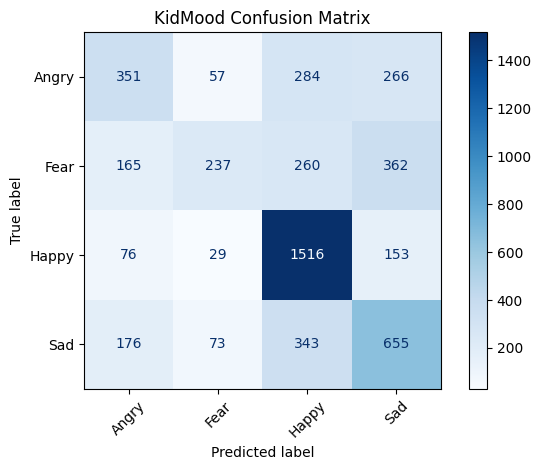

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(CLASS_NAMES))))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap='Blues', xticks_rotation=45)
plt.title('KidMood Confusion Matrix')
plt.tight_layout()
plt.savefig(viz_dir / 'confusion_matrix.png', dpi=160)
plt.show()
